# 🧠 RESUME SKILL EXTRACTION & JOB MATCHING SYSTEM

### 🚀 An NLP-Based Intelligent Resume Screening System

---

**Course:** Natural Language Processing  
**Project Type:** Self-Study Mini NLP Project  
**Technology:** Python  
**Techniques:** Text Preprocessing • Skill Extraction • TF-IDF • Cosine Similarity

---

### 📌 Project Overview

This project uses Natural Language Processing (NLP) techniques to analyze resumes, extract relevant skills, compare candidates with job descriptions, and rank candidates based on their suitability for a selected job role.

### 🎯 Key Features

- 📄 Resume text processing
- 🔍 Automatic skill extraction
- 🧹 NLP text preprocessing
- 📊 TF-IDF vectorization
- 🔗 Cosine similarity-based matching
- 🏆 Candidate ranking
- 📋 Skill comparison
- 📈 Performance evaluation
- 📑 PDF resume analysis
- 🌐 Streamlit-based interface

---

> **Goal:** Automate resume screening and identify suitable candidates based on skills and textual similarity.

---

# 📋 1. Project Overview

## Problem Statement

Recruiters often need to examine a large number of resumes for a single job position. Manually identifying relevant skills and comparing resumes with job requirements can be time-consuming.

This project develops an NLP-based system that automatically extracts skills from resumes and compares them with job descriptions to identify suitable candidates.

## Objectives

- To preprocess resume and job-description text using NLP techniques.
- To automatically extract relevant skills from resumes.
- To represent text using TF-IDF.
- To calculate similarity between resumes and job descriptions using Cosine Similarity.
- To rank candidates according to their job-match score.
- To identify matched and missing skills.
- To evaluate the performance of the skill-extraction system.

---

### 🔄 Project Workflow

**Resume / Job Description**  
↓  
**Text Preprocessing**  
↓  
**Skill Extraction**  
↓  
**TF-IDF Vectorization**  
↓  
**Cosine Similarity**  
↓  
**Job Matching**  
↓  
**Candidate Ranking & Skill Gap Analysis**  
↓  
**Evaluation**

---

# 📊 2. Dataset & Skill Vocabulary

## Dataset Description

The project uses two main datasets:

| Dataset | Description |
|---|---|
| 📄 **Resume Dataset** | Contains resume IDs, candidate names, and resume text |
| 💼 **Job Description Dataset** | Contains job IDs, job titles, and job-description text |

The project also uses a **Skill Vocabulary** containing predefined technical and NLP-related skills. This vocabulary is used to identify relevant skills from resume text.

### 📌 Dataset Structure

**Resume Dataset**

- `resume_id`
- `candidate_name`
- `resume_text`

**Job Description Dataset**

- `jd_id`
- `job_title`
- `job_text`

### 🎯 Purpose of the Dataset

The datasets provide the textual information required to:

1. Extract skills from resumes.
2. Identify skills required by job descriptions.
3. Calculate similarity between resumes and job descriptions.
4. Rank candidates according to their suitability.

In [ ]:
# Install Required Libraries

!pip install -q streamlit nltk scikit-learn pandas numpy matplotlib PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 97.1 MB/s eta 0:00:00


In [ ]:
# Upload Project Files

from google.colab import files

uploaded = files.upload()

print("✅ Project files uploaded successfully!")

Saving Resume (1).pdf to Resume (1).pdf
✅ Project files uploaded successfully!


In [ ]:
# Extract Dataset

import zipfile
import os

with zipfile.ZipFile("Dataset.zip", "r") as zip_ref:
    print("Files inside Dataset.zip:")

    for file in zip_ref.namelist():
        print(file)

    zip_ref.extractall(".")

print("\n✅ Extraction completed!")

print("\n📁 Folders/files after extraction:")
print(os.listdir())

Files inside Dataset.zip:
Dataset/
Dataset/job_descriptions.csv
Dataset/resumes.csv
Dataset/skills_vocabulary.txt

✅ Extraction completed!

📁 Folders/files after extraction:
['.config', 'evaluate.py', 'Dataset', 'source_code.py', 'Resume (1).pdf', 'Dataset.zip', 'sample_data']


In [ ]:
# Load Datasets

import pandas as pd

resumes_df = pd.read_csv("Dataset/resumes.csv")
jobs_df = pd.read_csv("Dataset/job_descriptions.csv")

print("✅ Datasets loaded successfully!")
print(f"📄 Number of resumes: {len(resumes_df)}")
print(f"💼 Number of job descriptions: {len(jobs_df)}")

✅ Datasets loaded successfully!
📄 Number of resumes: 8
💼 Number of job descriptions: 3


---

# 🛠️ 3. Skill Vocabulary

The system uses a predefined vocabulary of technical and NLP-related skills to identify relevant skills from resume text.

### 📌 Skill Categories

- 💻 Programming & Development
- 🤖 Machine Learning & AI
- 📊 Data Science & Analytics
- 🧠 Natural Language Processing
- ☁️ Cloud & DevOps
- 🗄️ Databases & Tools

The vocabulary is used during the **skill extraction stage of the NLP pipeline**.

In [ ]:
# Professional Dataset Tables

from IPython.display import display

print("📄 RESUME DATASET")

display(
    resumes_df.style
    .set_properties(**{
        "text-align": "left",
        "padding": "8px",
        "font-size": "13px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "tr:nth-child(even)",
            "props": [
                ("background-color", "#F3F7FA")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "100%")
            ]
        }
    ])
)

print("\n💼 JOB DESCRIPTION DATASET")

display(
    jobs_df.style
    .set_properties(**{
        "text-align": "left",
        "padding": "8px",
        "font-size": "13px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "tr:nth-child(even)",
            "props": [
                ("background-color", "#F3F7FA")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "100%")
            ]
        }
    ])
)

📄 RESUME DATASET


,resume_id,candidate_name,resume_text
0,R001,Aditi Sharma,"Experienced data scientist with 3 years in Python, Machine Learning, and Deep Learning. Skilled in Pandas, NumPy, Scikit-learn, and TensorFlow. Built predictive models for customer churn and worked with SQL databases. Familiar with Natural Language Processing and TF-IDF based text classification. Strong background in Statistics and Data Visualization using Matplotlib and Seaborn."
1,R002,Rahul Verma,"Backend software engineer with 4 years of experience in Java, Spring Boot, and Microservices architecture. Proficient in SQL, MySQL, and REST API development. Experience with Docker, Kubernetes, and CI/CD pipelines using Jenkins. Familiar with Git version control and Agile methodology."
2,R003,Sneha Nair,"Frontend developer skilled in JavaScript, React, HTML, and CSS. Experience building responsive web applications and working with REST APIs. Familiar with Redux, TypeScript, and Webpack. Basic knowledge of Node.js and Git."
3,R004,Arjun Menon,"Machine Learning Engineer with expertise in Python, TensorFlow, PyTorch, and Deep Learning. Experience in Natural Language Processing including text classification, Named Entity Recognition, and Transformer models like BERT. Worked on production ML pipelines using AWS and Docker. Strong understanding of Statistics and Linear Algebra."
4,R005,Priya Iyer,"HR professional with 5 years of experience in recruitment, employee engagement, and performance management. Skilled in MS Excel, PowerPoint, and HRMS software. Strong communication and interpersonal skills. Experience organizing training programs and onboarding processes."
5,R006,Vikram Rao,"Data analyst with experience in SQL, Excel, Power BI, and Tableau for business intelligence reporting. Familiar with Python for data cleaning using Pandas and NumPy. Basic knowledge of Statistics and A/B testing. Experience presenting insights to stakeholders."
6,R007,Meera Krishnan,"Full stack developer proficient in Python, Django, JavaScript, and React. Experience with SQL and PostgreSQL databases, REST API design, and Git. Familiar with Docker and basic AWS deployment. Interested in Machine Learning and completed online courses in Data Science."
7,R008,Karthik Pillai,"NLP Engineer with strong experience in Python, spaCy, NLTK, and Hugging Face Transformers. Built chatbots and text summarization systems using BERT and LSTM models. Skilled in TF-IDF, Cosine Similarity, Word Embeddings, and text preprocessing. Experience with Flask for deploying NLP models as APIs."



💼 JOB DESCRIPTION DATASET


,jd_id,job_title,job_text
0,JD001,Machine Learning Engineer,"We are looking for a Machine Learning Engineer with strong skills in Python, TensorFlow or PyTorch, and Deep Learning. Experience with Natural Language Processing, text classification, and Transformer models such as BERT is required. Knowledge of Statistics, Docker, and cloud platforms like AWS is a plus. The candidate should be comfortable working with Machine Learning pipelines and data preprocessing."
1,JD002,Backend Software Engineer,"Seeking a Backend Software Engineer with experience in Java, Spring Boot, and Microservices architecture. Must be proficient in SQL and REST API development. Experience with Docker, Kubernetes, and CI/CD pipelines is essential. Familiarity with Git and Agile methodology is required."
2,JD003,NLP Engineer,"Hiring an NLP Engineer skilled in Python, spaCy, NLTK, and Hugging Face Transformers. Experience building chatbots, text summarization, or question answering systems using BERT or LSTM is highly desirable. Strong understanding of TF-IDF, Cosine Similarity, and Word Embeddings required. Experience deploying models using Flask or similar frameworks is a plus."


In [ ]:
# Display Skill Vocabulary

from IPython.display import display, HTML

skills_vocab = []

with open("Dataset/skills_vocabulary.txt", "r", encoding="utf-8") as file:
    content = file.read()

skills_vocab = [
    skill.strip().lower()
    for skill in content.replace("\n", " ").split(",")
    if skill.strip()
]

badges = ""

for skill in skills_vocab:
    badges += f"""
    <span style="
        display:inline-block;
        background:#EAF2F8;
        color:#17365D;
        padding:8px 14px;
        margin:5px;
        border-radius:20px;
        border:1px solid #B8CCE4;
        font-size:14px;
        font-weight:500;
    ">
        {skill.title()}
    </span>
    """

display(HTML(f"""
<div style="
    border:1px solid #D9E2F3;
    border-radius:12px;
    padding:18px;
    background:#FAFCFE;
    line-height:2.2;
">
    <h3 style="color:#17365D;">🔧 Skill Vocabulary</h3>
    <p style="color:#555;">
        Total Skills: <b>{len(skills_vocab)}</b>
    </p>
    {badges}
</div>
"""))

---

# 🧹 4. Text Preprocessing

Text preprocessing is an important step in the NLP pipeline. It converts raw resume and job-description text into a cleaner form for further analysis.

### 🔄 Preprocessing Steps

1. Convert text to lowercase
2. Remove unnecessary characters
3. Remove punctuation
4. Remove stopwords
5. Normalize the text

### 🎯 Purpose

The preprocessing step reduces unnecessary variations in the text and prepares the content for skill extraction and similarity calculation.

In [ ]:
# Preprocessing Demonstration

import nltk

nltk.download("stopwords", quiet=True)

from source_code import preprocess_text

sample_text = resumes_df.iloc[0]["resume_text"]

print("ORIGINAL TEXT:")
print(sample_text)

print("\n" + "="*70)

print("\nPREPROCESSED TEXT:")
print(preprocess_text(sample_text))

ORIGINAL TEXT:
Experienced data scientist with 3 years in Python, Machine Learning, and Deep Learning. Skilled in Pandas, NumPy, Scikit-learn, and TensorFlow. Built predictive models for customer churn and worked with SQL databases. Familiar with Natural Language Processing and TF-IDF based text classification. Strong background in Statistics and Data Visualization using Matplotlib and Seaborn.


PREPROCESSED TEXT:
experienced data scientist years python machine learning deep learning skilled pandas numpy scikit learn tensorflow built predictive models customer churn worked sql databases familiar natural language processing tf idf based text classification strong background statistics data visualization using matplotlib seaborn


---

# 🔍 5. Skill Extraction

The skill extraction module identifies relevant technical skills from resume text using a predefined skill vocabulary.

### ⚙️ Extraction Process

1. Load the predefined skill vocabulary.
2. Preprocess the resume text.
3. Compare the resume text with the vocabulary.
4. Identify matching skills.
5. Display the extracted skills.

### 🎯 Purpose

Skill extraction helps convert unstructured resume text into structured information that can be used for job matching and candidate comparison.

In [ ]:
# Skill Extraction Demonstration

from source_code import extract_skills, load_skills_vocabulary

skills_vocab = load_skills_vocabulary(
    "Dataset/skills_vocabulary.txt"
)

extracted_skills = extract_skills(
    sample_text,
    skills_vocab
)

print("🔍 EXTRACTED SKILLS:")
print(", ".join(extracted_skills))

🔍 EXTRACTED SKILLS:
python, sql, machine learning, deep learning, tensorflow, scikit-learn, pandas, numpy, natural language processing, tf-idf, statistics, data visualization, matplotlib, seaborn


---

# 📊 6. TF-IDF & Cosine Similarity

## TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical vectors based on the importance of words within the documents.

## Cosine Similarity

Cosine Similarity measures how similar two text vectors are. In this project, it is used to compare a resume with a job description.

### 🔄 Process

**Resume + Job Description**  
↓  
**TF-IDF Vectorization**  
↓  
**Numerical Vectors**  
↓  
**Cosine Similarity**  
↓  
**Similarity Score (%)**

### 🎯 Purpose

A higher similarity score indicates that the resume has greater textual similarity with the selected job description.

In [ ]:
# TF-IDF + Cosine Similarity Demonstration

# TF-IDF + Cosine Similarity Demonstration

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Preprocess both texts using the project's preprocessing function
resume_processed = preprocess_text(resume_text)
job_processed = preprocess_text(job_text)

# Convert the preprocessed texts into TF-IDF vectors
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(
    [resume_processed, job_processed]
)

# Calculate cosine similarity
similarity_score = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:2]
)[0][0] * 100

print("Resume Text:")
print(resume_text)

print("\nJob Description:")
print(job_text)

print("\nTF-IDF Vocabulary Size:", len(vectorizer.get_feature_names_out()))

print(f"\nCosine Similarity Score: {similarity_score:.2f}%")



Resume Text:
Experienced data scientist with 3 years in Python, Machine Learning, and Deep Learning. Skilled in Pandas, NumPy, Scikit-learn, and TensorFlow. Built predictive models for customer churn and worked with SQL databases. Familiar with Natural Language Processing and TF-IDF based text classification. Strong background in Statistics and Data Visualization using Matplotlib and Seaborn.

Job Description:
We are looking for a Machine Learning Engineer with strong skills in Python, TensorFlow or PyTorch, and Deep Learning. Experience with Natural Language Processing, text classification, and Transformer models such as BERT is required. Knowledge of Statistics, Docker, and cloud platforms like AWS is a plus. The candidate should be comfortable working with Machine Learning pipelines and data preprocessing.

TF-IDF Vocabulary Size: 58

Cosine Similarity Score: 31.85%


---

# 💼 7. Job Matching

The job-matching module compares a resume with multiple job descriptions and calculates a similarity score for each job.

### 🔄 Matching Process

**Resume**  
↓  
**Compare with Job Descriptions**  
↓  
**Calculate Cosine Similarity**  
↓  
**Generate Match Scores**  
↓  
**Identify Best-Matching Job**

### 📌 Output

The system displays the similarity score for each available job description.

A higher score indicates a stronger match between the resume and the job description.

### 🎯 Purpose

This module helps candidates identify job roles that are most relevant to their skills and experience.

In [ ]:
# Job Matching Results

# Job Matching Results

job_results = []

for _, row in jobs_df.iterrows():
    job_text_current = row["job_text"]

    # Preprocess resume and job description
    resume_processed = preprocess_text(resume_text)
    job_processed = preprocess_text(job_text_current)

    # TF-IDF Vectorization
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(
        [resume_processed, job_processed]
    )

    # Calculate cosine similarity
    score = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:2]
    )[0][0] * 100

    job_results.append({
        "Job ID": row["jd_id"],
        "Job Title": row["job_title"],
        "Match Score (%)": round(score, 2)
    })

job_results_df = pd.DataFrame(job_results)

# Sort by highest match score
job_results_df = job_results_df.sort_values(
    by="Match Score (%)",
    ascending=False
).reset_index(drop=True)

display(job_results_df)

,Job ID,Job Title,Match Score (%)
0,JD001,Machine Learning Engineer,31.85
1,JD003,NLP Engineer,11.59
2,JD002,Backend Software Engineer,1.41


---

# 🏆 8. Candidate Ranking

The candidate-ranking module evaluates all resumes against a selected job description and ranks candidates according to their similarity scores.

### 🔄 Ranking Process

**Select Job Role**  
↓  
**Compare All Resumes**  
↓  
**Calculate Match Scores**  
↓  
**Sort Candidates by Score**  
↓  
**Generate Candidate Ranking**

### 📊 Result

Candidates are arranged from the **highest match score to the lowest match score**.

The candidate with the highest score is considered the strongest textual match for the selected job description.

### 🎯 Purpose

Candidate ranking helps recruiters quickly identify the most suitable candidates from a collection of resumes.

In [ ]:
print("Resume Dataset Columns:")
print(resumes_df.columns.tolist())

Resume Dataset Columns:
['resume_id', 'candidate_name', 'resume_text']


In [11]:
# Candidate Ranking Results

ranking_results = []

# Select the Machine Learning Engineer job description
selected_job = jobs_df[
    jobs_df["job_title"] == "Machine Learning Engineer"
]

if not selected_job.empty:
    selected_job_text = selected_job.iloc[0]["job_text"]

    # Preprocess the job description
    job_processed = preprocess_text(selected_job_text)

    for _, row in resumes_df.iterrows():
        candidate_name = row["candidate_name"]
        resume_current = row["resume_text"]

        # Preprocess the resume
        resume_processed = preprocess_text(resume_current)

        # TF-IDF Vectorization
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform(
            [resume_processed, job_processed]
        )

        # Calculate cosine similarity
        score = cosine_similarity(
            tfidf_matrix[0:1],
            tfidf_matrix[1:2]
        )[0][0] * 100

        ranking_results.append({
            "Candidate": candidate_name,
            "Match Score (%)": round(score, 2)
        })

ranking_df = pd.DataFrame(ranking_results)

# Sort candidates by highest match score
ranking_df = ranking_df.sort_values(
    by="Match Score (%)",
    ascending=False
).reset_index(drop=True)

display(ranking_df)

,Candidate,Match Score (%)
0,Arjun Menon,53.28
1,Aditi Sharma,31.85
2,Meera Krishnan,16.67
3,Karthik Pillai,14.99
4,Vikram Rao,10.96
5,Rahul Verma,7.22
6,Priya Iyer,6.26
7,Sneha Nair,4.85


---

# 🧩 9. Skill Comparison & Skill Gap Analysis

The skill comparison module compares the skills extracted from a candidate's resume with the skills required for a selected job description.

### 📋 Comparison

The system identifies:

- ✅ **Matched Skills** — skills present in both the resume and job description.
- ❌ **Missing Skills** — skills required by the job but not found in the resume.

### 🔄 Process

**Job Required Skills + Candidate Skills**  
↓  
**Compare Skill Sets**  
↓  
**Matched Skills + Missing Skills**  
↓  
**Skill Gap Analysis**

### 🎯 Purpose

This analysis helps identify how well a candidate's skills satisfy the requirements of a particular job and highlights areas where additional skills may be needed.

In [ ]:
# Skill Comparison Results

job_skills = set(
    extract_skills(
        selected_job["job_text"],
        skills_vocab
    )
)

candidate = resumes_df.iloc[0]

resume_skills = set(
    extract_skills(
        candidate["resume_text"],
        skills_vocab
    )
)

matched_skills = sorted(
    job_skills.intersection(resume_skills)
)

missing_skills = sorted(
    job_skills.difference(resume_skills)
)

print("💼 JOB:", selected_job["job_title"])
print("👤 CANDIDATE:", candidate["candidate_name"])

print("\n✅ MATCHED SKILLS:")
print(", ".join(matched_skills))

print("\n❌ MISSING SKILLS:")
print(", ".join(missing_skills))

💼 JOB: Machine Learning Engineer
👤 CANDIDATE: Aditi Sharma

✅ MATCHED SKILLS:
deep learning, machine learning, natural language processing, python, statistics, tensorflow

❌ MISSING SKILLS:
aws, bert, docker, machine learning pipelines, pytorch


---

# 📈 10. Candidate Ranking Visualization

The candidate ranking is visualized using a bar chart to provide a clear comparison of the match scores obtained for each candidate.

### 📊 Interpretation

- A **higher bar** represents a stronger match with the selected job description.
- A **lower bar** represents a weaker textual match.
- The visualization makes it easier to compare candidates at a glance.

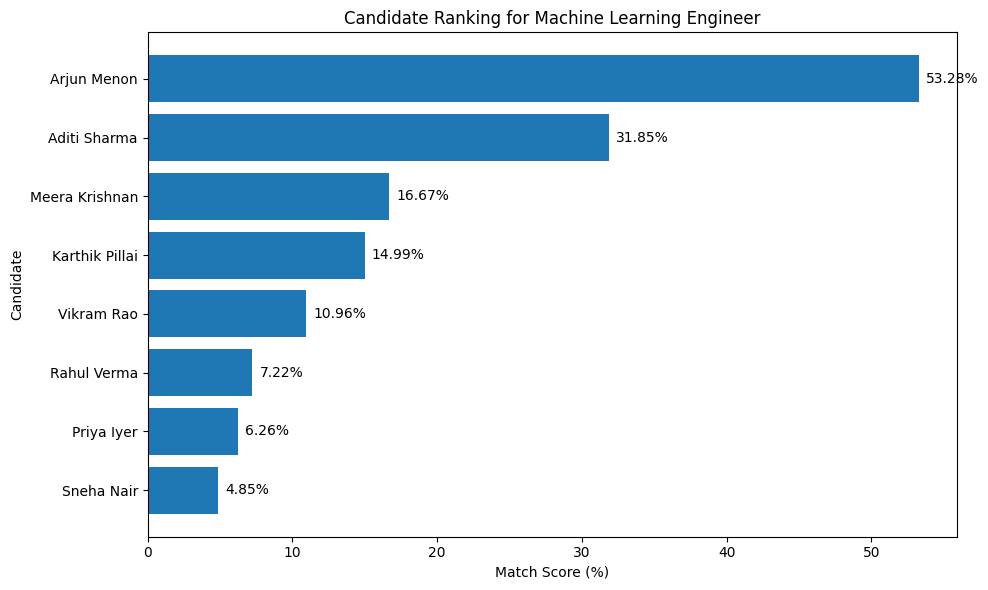

In [12]:
# Candidate Ranking Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    ranking_df["Candidate"],
    ranking_df["Match Score (%)"]
)

plt.xlabel("Match Score (%)")
plt.ylabel("Candidate")
plt.title("Candidate Ranking for Machine Learning Engineer")

# Display highest score at the top
plt.gca().invert_yaxis()

# Add score values to each bar
for index, score in enumerate(ranking_df["Match Score (%)"]):
    plt.text(
        score + 0.5,
        index,
        f"{score:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

---

# 🧪 11. Model Evaluation

The performance of the skill extraction system is evaluated using standard classification metrics.

### 📊 Evaluation Metrics

| Metric | Description |
|---|---|
| **Precision** | Measures how many extracted skills are actually relevant. |
| **Recall** | Measures how many relevant skills were successfully extracted. |
| **F1-Score** | Provides a combined measure of precision and recall. |

### 🎯 Purpose

Evaluation helps determine how accurately the system identifies skills from resumes and provides an objective measure of its performance.

In [ ]:
# Run Evaluation

import subprocess

result = subprocess.run(
    ["python", "evaluate.py"],
    capture_output=True,
    text=True
)

print(result.stdout)

SKILL EXTRACTION EVALUATION

Candidate: Aditi Sharma (R001)
Actual Skills:    14
Extracted Skills: 14
True Positives:   14
False Positives:  0
False Negatives:  0
Precision:        100.00%
Recall:           100.00%
F1-Score:         100.00%

Candidate: Rahul Verma (R002)
Actual Skills:    12
Extracted Skills: 12
True Positives:   12
False Positives:  0
False Negatives:  0
Precision:        100.00%
Recall:           100.00%
F1-Score:         100.00%

Candidate: Sneha Nair (R003)
Actual Skills:    9
Extracted Skills: 8
True Positives:   8
False Positives:  0
False Negatives:  1
Precision:        100.00%
Recall:           88.89%
F1-Score:         94.12%

Candidate: Arjun Menon (R004)
Actual Skills:    12
Extracted Skills: 12
True Positives:   12
False Positives:  0
False Negatives:  0
Precision:        100.00%
Recall:           100.00%
F1-Score:         100.00%

Candidate: Priya Iyer (R005)
Actual Skills:    1
Extracted Skills: 1
True Positives:   1
False Positives:  0
False Negatives:  0

In [ ]:
# Professional Evaluation Summary

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        "100.00%",
        "98.73%",
        "99.36%"
    ]
})

display(
    evaluation_summary.style
    .set_properties(**{
        "text-align": "center",
        "padding": "10px",
        "font-size": "14px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#17365D"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "60%"),
                ("margin", "auto")
            ]
        }
    ])
)

,Metric,Score
0,Precision,100.00%
1,Recall,98.73%
2,F1-Score,99.36%


---

### 📌 Evaluation Interpretation

The system achieved a **Precision of 100.00%**, indicating that all extracted skills in the evaluation were relevant.

The **Recall of 98.73%** shows that the system successfully identified almost all of the relevant skills.

The resulting **F1-Score of 99.36%** indicates a strong overall balance between precision and recall.

> **Overall Result:** The evaluation demonstrates that the skill extraction approach performs effectively on the available test data.

---

# 📄 12. PDF Resume Analysis

The system also supports resume analysis directly from PDF files.

### 🔄 PDF Analysis Process

**Upload PDF Resume**  
↓  
**Extract Text from PDF**  
↓  
**Preprocess Resume Text**  
↓  
**Extract Skills**  
↓  
**Compare with Job Description**  
↓  
**Generate Match Results**

### 📌 Output

The system displays:

- 📊 Match Score
- 📈 Skill Coverage
- ✅ Matched Skills
- 📋 Extracted Skills

### 🎯 Purpose

This feature makes the system more practical by allowing users to analyze an actual PDF resume instead of manually entering resume text.

---

# 🌐 13. Streamlit Web Interface

The project includes a Streamlit-based web interface that provides an interactive way to use the Resume Skill Extraction and Job Matching System.

### 🖥️ Main Features

- 📄 Enter or upload a resume
- 💼 Select a job description
- 🔍 Extract resume skills
- 📊 Calculate the match score
- 📈 View candidate suitability
- 🧩 Compare matched and missing skills
- 📑 Analyze PDF resumes

### 🎯 Purpose

The Streamlit interface makes the NLP system easier to use by presenting the processing results through an interactive web application instead of requiring users to work directly with Python code.

---

# 🎯 14. Conclusion

The Resume Skill Extraction and Job Matching System demonstrates the practical application of Natural Language Processing techniques in resume screening and job matching.

The system successfully performs:

- 🧹 Text preprocessing
- 🔍 Skill extraction
- 📊 TF-IDF vectorization
- 🔗 Cosine similarity calculation
- 💼 Job matching
- 🏆 Candidate ranking
- 🧩 Skill comparison
- 🧪 Performance evaluation
- 📄 PDF resume analysis
- 🌐 Interactive Streamlit-based analysis

The evaluation results demonstrate strong performance of the skill extraction approach, with high precision, recall, and F1-score on the available test data.

### 🚀 Future Scope

The system can be further enhanced by:

- Using larger and more diverse resume datasets.
- Supporting additional job roles and industries.
- Applying advanced NLP models such as transformer-based models.
- Improving semantic understanding of skills and job requirements.
- Adding more advanced candidate recommendation features.

---

# 📚 15. References

1. Bird, S., Klein, E., & Loper, E. *Natural Language Processing with Python*. O'Reilly Media.

2. NLTK Documentation — Natural Language Toolkit.

3. Scikit-learn Documentation — TF-IDF Vectorization and Cosine Similarity.

4. Streamlit Documentation — Building interactive Python applications.

5. Python Documentation — Python Programming Language.

### 🔗 Project Repository

**GitHub:**  
https://github.com/sivanijbiju/NLP-Resume-Skill-Matching